In [1]:
import numpy as np
import pandas as pd
import scipy
import yfinance as yf
import arch
import matplotlib.pyplot as plt
import plotly

import sys
sys.path.append('..')

# Quick test — fetch SPY price
spy = yf.Ticker("SPY")
hist = spy.history(period="5d")
print(hist[['Close']].tail())
print("\nAll packages imported successfully")
print(f"SPY latest close: ${hist['Close'].iloc[-1]:.2f}")

                                Close
Date                                 
2026-06-08 00:00:00-04:00  739.219971
2026-06-09 00:00:00-04:00  737.049988
2026-06-10 00:00:00-04:00  725.429993
2026-06-11 00:00:00-04:00  737.760010
2026-06-12 00:00:00-04:00  741.750000

All packages imported successfully
SPY latest close: $741.75


In [2]:
import logging
logging.basicConfig(level=logging.INFO)


from src.data import fetch_spot_price, fetch_risk_free_rate

spot = fetch_spot_price()
rate = fetch_risk_free_rate()

print(f"SPY spot: {spot:.2f}")
print(f"Risk-free rate: {rate:.4%}")

INFO:src.data:Fetched spot price for SPY: 741.75
INFO:src.data:Fetched risk-free rate from ^IRX: 3.6180%


SPY spot: 741.75
Risk-free rate: 3.6180%


In [3]:
from src.data import fetch_options_chain, fetch_spot_price

spot = fetch_spot_price()
expiries = yf.Ticker("SPY").options
print(expiries[:5])  # see what's available

chain = fetch_options_chain("SPY", expiries[0], spot_price=spot)
print(chain.head())
print(f"\n{len(chain)} cleaned rows")

INFO:src.data:Fetched spot price for SPY: 741.75
INFO:src.data:Cleaned options chain for SPY 2026-06-15: kept 161/229 rows


('2026-06-15', '2026-06-16', '2026-06-17', '2026-06-18', '2026-06-22')
   strike option_type  mid_price     bid     ask  volume  open_interest  \
0   500.0        call    242.535  241.15  243.92    66.0              8   
1   540.0        call    202.550  201.17  203.93    12.0              6   
2   635.0        call    107.585  106.17  109.00     2.0              1   
3   640.0        call    102.580  101.17  103.99     2.0              4   
4   655.0        call     87.555   86.19   88.92     1.0              8   

       expiry        T  
0  2026-06-15  0.00274  
1  2026-06-15  0.00274  
2  2026-06-15  0.00274  
3  2026-06-15  0.00274  
4  2026-06-15  0.00274  

161 cleaned rows


In [4]:
from src.vol_surface import compute_surface
import yfinance as yf

all_expiries = yf.Ticker("SPY").options
# pick a handful spanning different horizons — skip the very nearest (T≈0) ones for now
expiries = all_expiries[3:8]
print(expiries)

surface = compute_surface("SPY", expiries)
print(surface.head())
print(surface["implied_vol"].describe())

INFO:src.data:Fetched spot price for SPY: 741.75
INFO:src.data:Fetched risk-free rate from ^IRX: 3.6180%


('2026-06-18', '2026-06-22', '2026-06-26', '2026-06-30', '2026-07-02')


INFO:src.data:Cleaned options chain for SPY 2026-06-18: kept 370/498 rows
INFO:src.data:Cleaned options chain for SPY 2026-06-22: kept 41/41 rows
INFO:src.data:Cleaned options chain for SPY 2026-06-26: kept 286/296 rows
INFO:src.data:Cleaned options chain for SPY 2026-06-30: kept 583/611 rows
INFO:src.data:Cleaned options chain for SPY 2026-07-02: kept 256/263 rows


Surface built: 888 options, 0 skipped (no IV solution)
   strike option_type      expiry         T  mid_price  implied_vol
0   742.0        call  2026-06-18  0.010959      5.930     0.190723
1   743.0        call  2026-06-18  0.010959      5.365     0.188090
2   744.0        call  2026-06-18  0.010959      4.830     0.185529
3   745.0        call  2026-06-18  0.010959      4.325     0.183011
4   746.0        call  2026-06-18  0.010959      3.855     0.180679
count    888.000000
mean       0.333134
std        0.234461
min        0.115532
25%        0.166151
50%        0.237697
75%        0.451490
max        1.450010
Name: implied_vol, dtype: float64


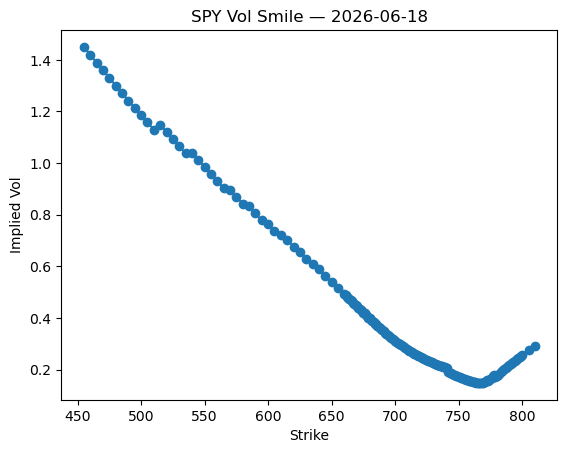

In [5]:
import matplotlib.pyplot as plt

near_expiry = surface[surface["expiry"] == "2026-06-18"].sort_values("strike")
plt.plot(near_expiry["strike"], near_expiry["implied_vol"], marker='o')
plt.xlabel("Strike")
plt.ylabel("Implied Vol")
plt.title("SPY Vol Smile — 2026-06-18")
plt.show()

Today: 2026-06-14, target ~30d: 2026-07-14, closest expiry: 2026-07-17


INFO:src.data:Fetched spot price for SPY: 741.75
INFO:src.data:Fetched risk-free rate from ^IRX: 3.6180%
INFO:src.data:Cleaned options chain for SPY 2026-07-17: kept 342/365 rows


Surface built: 201 options, 0 skipped (no IV solution)


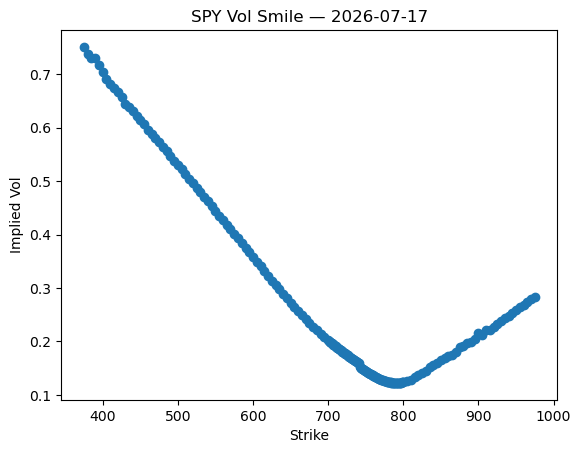

count    201.000000
mean       0.263609
std        0.173245
min        0.122403
25%        0.140794
50%        0.186317
75%        0.314045
max        0.751154
Name: implied_vol, dtype: float64


In [6]:
import datetime

today = datetime.date.today()
target = today + datetime.timedelta(days=30)

# find the expiry closest to 30 days out
closest_expiry = min(all_expiries, key=lambda e: abs((datetime.date.fromisoformat(e) - target).days))
print(f"Today: {today}, target ~30d: {target}, closest expiry: {closest_expiry}")

surface_30d = compute_surface("SPY", [closest_expiry])

plt.plot(
    surface_30d.sort_values("strike")["strike"],
    surface_30d.sort_values("strike")["implied_vol"],
    marker='o'
)
plt.xlabel("Strike")
plt.ylabel("Implied Vol")
plt.title(f"SPY Vol Smile — {closest_expiry}")
plt.show()

print(surface_30d["implied_vol"].describe())

In [7]:
vix = fetch_spot_price("^VIX")
print(f"VIX: {vix:.2f}")

# find the strike(s) closest to spot — that's your ATM IV
atm_rows = surface_30d.iloc[(surface_30d["strike"] - spot).abs().argsort()[:2]]
print(atm_rows[["strike", "option_type", "implied_vol"]])

INFO:src.data:Fetched spot price for ^VIX: 17.68


VIX: 17.68
     strike option_type  implied_vol
0     742.0        call     0.151911
200   741.0         put     0.159708
